# МОДЕЛИРОВАНИЕ СИСТЕМЫ РЕССЛЕРА ЧЕРЕЗ NEURAL ODE

В этом ноутбуке:

- данные генерируются по классической системе Ресслера;
- обучение идёт на нескольких эталонных траекториях;
- используется callback для сохранения лучшей модели по валидационной ошибке;
- запускается серия экспериментов с разной архитектурой и гиперпараметрами;
- для каждой конфигурации считаются численные метрики, по которым можно сделать вывод о качестве обучения.

In [ ]:
!pip install -q torchdiffeq torchinfo pandas

In [ ]:
%matplotlib inline

import os
import copy
import time
import random
from dataclasses import dataclass
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from mpl_toolkits.mplot3d import Axes3D
from torchdiffeq import odeint_adjoint as odeint
from torchinfo import summary

## НАСТРОЙКИ ЭКСПЕРИМЕНТА

In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

batch_size = 64
batch_time = 20
data_size = 2500
niters = 2000
test_freq = 100

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"Device: {device}")

Device: cpu


## ПАПКИ ДЛЯ АРТЕФАКТОВ

In [ ]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("docs", exist_ok=True)

## ПАРАМЕТРЫ СИСТЕМЫ РЁССЛЕРА

In [ ]:
a = 0.2
b = 0.2
c = 5.7

## НАЧАЛЬНЫЕ УСЛОВИЯ И ВРЕМЕННАЯ СЕТКА

In [ ]:
t = torch.linspace(0.0, 50.0, data_size).to(device)

train_y0_list = torch.tensor([
    [0.0,  1.0,  0.0],
    [0.2,  0.8,  0.1],
    [-0.3, 1.2,  0.0],
], dtype=torch.float32).to(device)

val_y0 = torch.tensor([[0.5, -0.5, 0.2]], dtype=torch.float32).to(device)
test_y0 = torch.tensor([[-0.7, 0.4, 0.3]], dtype=torch.float32).to(device)

print("Число обучающих траекторий:", len(train_y0_list))
print("Валидационное начальное условие:", val_y0)
print("Тестовое начальное условие:", test_y0)

Число обучающих траекторий: 3
Валидационное начальное условие: tensor([[ 0.5000, -0.5000,  0.2000]])
Тестовое начальное условие: tensor([[-0.7000,  0.4000,  0.3000]])


## ПРАВАЯ ЧАСТЬ ИСТИННОЙ СИСТЕМЫ

In [ ]:
class RosslerSystem(nn.Module):
    """
    Классическая система Ресслера.
    По ней мы генерируем эталонные траектории.
    """

    def forward(self, t, y):
        x = y[..., 0]
        y_coord = y[..., 1]
        z = y[..., 2]

        dx = -y_coord - z
        dy = x + a * y_coord
        dz = b + z * (x - c)

        return torch.stack([dx, dy, dz], dim=-1)

## ГЕНЕРАЦИЯ ЭТАЛОННЫХ ТРАЕКТОРИЙ

In [ ]:
def generate_trajectory(system, y0, t_grid, method="dopri5"):
    with torch.no_grad():
        traj = odeint(system, y0, t_grid, method=method)
    return traj

def generate_train_dataset(system, y0_list, t_grid):
    trajectories = []

    for y0 in y0_list:
        y0 = y0.view(1, 3)
        traj = generate_trajectory(system, y0, t_grid)
        trajectories.append(traj)

    # форма:
    # (T, n_train_traj, 1, 3)
    return torch.stack(trajectories, dim=1)

true_system = RosslerSystem().to(device)

train_true_y = generate_train_dataset(true_system, train_y0_list, t)
val_true_y = generate_trajectory(true_system, val_y0, t)
test_true_y = generate_trajectory(true_system, test_y0, t)

print("train_true_y shape:", tuple(train_true_y.shape))
print("val_true_y shape:", tuple(val_true_y.shape))
print("test_true_y shape:", tuple(test_true_y.shape))

train_true_y shape: (2500, 3, 1, 3)
val_true_y shape: (2500, 1, 3)
test_true_y shape: (2500, 1, 3)


## ВЫБОРКА БАТЧЕЙ ИЗ НЕСКОЛЬКИХ ТРАЕКТОРИЙ

In [ ]:
def get_batch(train_data, batch_size, batch_time, t_grid):
    """
    Случайно выбираем:
    - номер обучающей траектории;
    - стартовый индекс окна внутри этой траектории.
    """

    num_traj = train_data.shape[1]

    start_idx = torch.from_numpy(
        np.random.choice(
            np.arange(train_data.shape[0] - batch_time, dtype=np.int64),
            batch_size,
            replace=True
        )
    ).long()

    traj_idx = torch.from_numpy(
        np.random.choice(
            np.arange(num_traj, dtype=np.int64),
            batch_size,
            replace=True
        )
    ).long()

    batch_y0 = train_data[start_idx, traj_idx]
    batch_t = t_grid[:batch_time]
    batch_y = torch.stack(
        [train_data[start_idx + i, traj_idx] for i in range(batch_time)],
        dim=0
    )

    return batch_y0.to(device), batch_t.to(device), batch_y.to(device)

## ВСПОМОГАТЕЛЬНЫЕ КЛАССЫ ДЛЯ ЛОГИРОВАНИЯ И CALLBACK

In [ ]:
class RunningAverageMeter:
    """
    Экспоненциально сглаженное среднее.
    Нужен для более аккуратного вывода во время обучения.
    """
    def __init__(self, momentum=0.99):
        self.momentum = momentum
        self.reset()

    def reset(self):
        self.val = None
        self.avg = 0.0

    def update(self, val):
        if self.val is None:
            self.avg = val
        else:
            self.avg = self.avg * self.momentum + val * (1 - self.momentum)
        self.val = val


class BestModelCheckpoint:
    """
    Callback, который запоминает лучшую модель по выбранной метрике.
    Здесь мы мониторим валидационный MAE на полной траектории.
    """
    def __init__(self, save_path, mode="min"):
        self.save_path = save_path
        self.mode = mode
        self.best_value = np.inf if mode == "min" else -np.inf
        self.best_iter = None

    def _is_improved(self, value):
        if self.mode == "min":
            return value < self.best_value
        return value > self.best_value

    def step(self, model, value, itr, config):
        if self._is_improved(value):
            self.best_value = float(value)
            self.best_iter = int(itr)

            checkpoint = {
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "best_value": float(value),
                "best_iter": int(itr),
                "config": config,
                "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            }

            torch.save(checkpoint, self.save_path)
            return True

        return False


class EarlyStopping:
    """
    Останавливает обучение, если валидационная ошибка долго не улучшается.
    """
    def __init__(self, patience=300, min_delta=1e-5, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.best_value = np.inf if mode == "min" else -np.inf
        self.counter = 0

    def step(self, value):
        improved = False

        if self.mode == "min":
            improved = value < (self.best_value - self.min_delta)
        else:
            improved = value > (self.best_value + self.min_delta)

        if improved:
            self.best_value = value
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

## МЕТРИКИ КАЧЕСТВА

In [ ]:
def trajectory_metrics(true_y, pred_y):
    """
    Считает набор численных метрик по всей траектории.
    """
    true_cpu = true_y.detach().cpu().squeeze(1)
    pred_cpu = pred_y.detach().cpu().squeeze(1)

    err = pred_cpu - true_cpu
    abs_err = err.abs()
    sq_err = err.pow(2)

    mae = abs_err.mean().item()
    mse = sq_err.mean().item()
    rmse = float(np.sqrt(mse))
    max_ae = abs_err.max().item()

    coord_mae = abs_err.mean(dim=0)
    coord_rmse = torch.sqrt(sq_err.mean(dim=0))

    true_mean = true_cpu.mean(dim=0, keepdim=True)
    ss_res = ((true_cpu - pred_cpu) ** 2).sum(dim=0)
    ss_tot = ((true_cpu - true_mean) ** 2).sum(dim=0) + 1e-8
    r2 = 1.0 - ss_res / ss_tot

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "max_ae": max_ae,
        "x_mae": coord_mae[0].item(),
        "y_mae": coord_mae[1].item(),
        "z_mae": coord_mae[2].item(),
        "x_rmse": coord_rmse[0].item(),
        "y_rmse": coord_rmse[1].item(),
        "z_rmse": coord_rmse[2].item(),
        "x_r2": r2[0].item(),
        "y_r2": r2[1].item(),
        "z_r2": r2[2].item(),
    }

## ВИЗУАЛИЗАЦИЯ ТРАЕКТОРИЙ

In [ ]:
def visualize_trajectory(true_y, pred_y, t_grid, title_prefix="", save_path=None):
    """
    Строим:
    1) x(t), y(t), z(t)
    2) 3D-траекторию
    3) фазовую проекцию (x, y)
    """

    true_np = true_y.detach().cpu().numpy()[:, 0, :]
    pred_np = pred_y.detach().cpu().numpy()[:, 0, :]
    t_np = t_grid.detach().cpu().numpy()

    fig = plt.figure(figsize=(16, 10), facecolor="white")

    ax_time = fig.add_subplot(221, frameon=False)
    ax_time.set_title(f"{title_prefix} | Координаты во времени")
    ax_time.set_xlabel("t")
    ax_time.set_ylabel("x, y, z")

    ax_time.plot(t_np, true_np[:, 0], label="x true")
    ax_time.plot(t_np, true_np[:, 1], label="y true")
    ax_time.plot(t_np, true_np[:, 2], label="z true")

    ax_time.plot(t_np, pred_np[:, 0], "--", label="x pred")
    ax_time.plot(t_np, pred_np[:, 1], "--", label="y pred")
    ax_time.plot(t_np, pred_np[:, 2], "--", label="z pred")

    ax_time.legend(loc="upper right")
    ax_time.grid(True, alpha=0.3)

    ax_3d = fig.add_subplot(222, projection="3d")
    ax_3d.set_title(f"{title_prefix} | Траектория в пространстве состояний")
    ax_3d.set_xlabel("x")
    ax_3d.set_ylabel("y")
    ax_3d.set_zlabel("z")
    ax_3d.plot(true_np[:, 0], true_np[:, 1], true_np[:, 2], label="Истина")
    ax_3d.plot(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], "--", label="Прогноз")
    ax_3d.legend()

    ax_phase = fig.add_subplot(223, frameon=False)
    ax_phase.set_title(f"{title_prefix} | Фазовая траектория (x, y)")
    ax_phase.set_xlabel("x")
    ax_phase.set_ylabel("y")
    ax_phase.plot(true_np[:, 0], true_np[:, 1], label="Истина")
    ax_phase.plot(pred_np[:, 0], pred_np[:, 1], "--", label="Прогноз")
    ax_phase.legend()
    ax_phase.grid(True, alpha=0.3)

    abs_err = np.abs(pred_np - true_np)
    ax_err = fig.add_subplot(224, frameon=False)
    ax_err.set_title(f"{title_prefix} | Абсолютная ошибка по координатам")
    ax_err.set_xlabel("t")
    ax_err.set_ylabel("|error|")
    ax_err.plot(t_np, abs_err[:, 0], label="|x error|")
    ax_err.plot(t_np, abs_err[:, 1], label="|y error|")
    ax_err.plot(t_np, abs_err[:, 2], label="|z error|")
    ax_err.legend()
    ax_err.grid(True, alpha=0.3)

    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

## НЕЙРОСЕТЕВАЯ ПРАВАЯ ЧАСТЬ

In [ ]:
def make_activation(name):
    name = name.lower()

    if name == "tanh":
        return nn.Tanh()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "elu":
        return nn.ELU()

    raise ValueError(f"Неизвестная активация: {name}")


class ODEFunc3D(nn.Module):
    """
    Нейросетевая аппроксимация правой части системы.
    """

    def __init__(self, hidden_dims=(64, 64, 32), activation="tanh"):
        super().__init__()

        layers = []
        in_features = 3

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            layers.append(make_activation(activation))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, 3))
        self.net = nn.Sequential(*layers)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.net.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0.0)

    def forward(self, t, y):
        return self.net(y)

## ФУНКЦИЯ ОБУЧЕНИЯ ОДНОГО ЭКСПЕРИМЕНТА

In [ ]:
def run_experiment(
    experiment_name,
    config,
    train_data,
    val_y0,
    val_true_y,
    test_y0,
    test_true_y,
    t_grid
):
    model = ODEFunc3D(
        hidden_dims=config["hidden_dims"],
        activation=config["activation"]
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=config["scheduler_patience"],
        min_lr=config["min_lr"]
    )

    checkpoint = BestModelCheckpoint(
        save_path=f"checkpoints/{experiment_name}_best.pt",
        mode="min"
    )

    early_stopping = EarlyStopping(
        patience=config["early_stopping_patience"],
        min_delta=config["early_stopping_min_delta"],
        mode="min"
    )

    time_meter = RunningAverageMeter(0.97)
    loss_meter = RunningAverageMeter(0.97)

    history = {
        "iter": [],
        "batch_mae": [],
        "val_mae": [],
        "lr": [],
    }

    end = time.time()

    for itr in range(1, config["niters"] + 1):
        model.train()
        optimizer.zero_grad()

        batch_y0, batch_t, batch_y = get_batch(
            train_data=train_data,
            batch_size=config["batch_size"],
            batch_time=config["batch_time"],
            t_grid=t_grid
        )

        pred_y = odeint(model, batch_y0, batch_t, method=config["solver"])
        loss = torch.mean(torch.abs(pred_y - batch_y))

        loss.backward()

        if config["grad_clip"] is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])

        optimizer.step()

        time_meter.update(time.time() - end)
        loss_meter.update(loss.item())

        if itr % config["test_freq"] == 0 or itr == 1:
            model.eval()

            with torch.no_grad():
                val_pred_y = odeint(model, val_y0, t_grid, method=config["solver"])
                val_metrics = trajectory_metrics(val_true_y, val_pred_y)

            val_mae = val_metrics["mae"]
            scheduler.step(val_mae)

            history["iter"].append(itr)
            history["batch_mae"].append(loss.item())
            history["val_mae"].append(val_mae)
            history["lr"].append(optimizer.param_groups[0]["lr"])

            print(
                f"[{experiment_name}] "
                f"Iter {itr:04d} | "
                f"Batch MAE {loss.item():.6f} | "
                f"Val MAE {val_mae:.6f} | "
                f"LR {optimizer.param_groups[0]['lr']:.2e} | "
                f"Time Avg {time_meter.avg:.4f}"
            )

            improved = checkpoint.step(model, val_mae, itr, config)

            if improved:
                print(
                    f"Лучшая модель обновлена: iter = {itr}, "
                    f"val_mae = {val_mae:.6f}"
                )

            should_stop = early_stopping.step(val_mae)
            if should_stop:
                print(f"Ранняя остановка в эксперименте {experiment_name} на итерации {itr}")
                break

        end = time.time()

    best_checkpoint = torch.load(
        f"checkpoints/{experiment_name}_best.pt",
        map_location=device
    )

    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        val_pred_y = odeint(model, val_y0, t_grid, method=config["solver"])
        test_pred_y = odeint(model, test_y0, t_grid, method=config["solver"])

    val_metrics = trajectory_metrics(val_true_y, val_pred_y)
    test_metrics = trajectory_metrics(test_true_y, test_pred_y)

    result_row = {
        "experiment": experiment_name,
        "hidden_dims": str(config["hidden_dims"]),
        "activation": config["activation"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "batch_time": config["batch_time"],
        "solver": config["solver"],
        "best_iter": best_checkpoint["best_iter"],
        "val_mae": val_metrics["mae"],
        "val_rmse": val_metrics["rmse"],
        "val_max_ae": val_metrics["max_ae"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_max_ae": test_metrics["max_ae"],
        "test_x_r2": test_metrics["x_r2"],
        "test_y_r2": test_metrics["y_r2"],
        "test_z_r2": test_metrics["z_r2"],
    }

    return {
        "model": model,
        "history": history,
        "val_pred_y": val_pred_y,
        "test_pred_y": test_pred_y,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "result_row": result_row,
    }

## НАБОР ЭКСПЕРИМЕНТОВ

Ниже собраны несколько конфигураций, которые отличаются архитектурой и гиперпараметрами. Это как раз позволяет сравнить, какая модель лучше восстанавливает динамику системы.

In [ ]:
experiment_configs = [
    {
        "name": "exp_baseline_tanh",
        "hidden_dims": (64, 64, 32),
        "activation": "tanh",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "batch_size": batch_size,
        "batch_time": batch_time,
        "niters": niters,
        "test_freq": test_freq,
        "solver": "dopri5",
        "grad_clip": 1.0,
        "scheduler_patience": 40,
        "min_lr": 1e-5,
        "early_stopping_patience": 250,
        "early_stopping_min_delta": 1e-5,
    },
    {
        "name": "exp_wide_tanh",
        "hidden_dims": (128, 128, 64),
        "activation": "tanh",
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "batch_size": batch_size,
        "batch_time": 25,
        "niters": niters,
        "test_freq": test_freq,
        "solver": "dopri5",
        "grad_clip": 1.0,
        "scheduler_patience": 40,
        "min_lr": 1e-5,
        "early_stopping_patience": 250,
        "early_stopping_min_delta": 1e-5,
    },
    {
        "name": "exp_deep_silu",
        "hidden_dims": (128, 128, 128, 64),
        "activation": "silu",
        "lr": 5e-4,
        "weight_decay": 1e-5,
        "batch_size": batch_size,
        "batch_time": 30,
        "niters": niters,
        "test_freq": test_freq,
        "solver": "dopri5",
        "grad_clip": 1.0,
        "scheduler_patience": 50,
        "min_lr": 1e-5,
        "early_stopping_patience": 300,
        "early_stopping_min_delta": 1e-5,
    },
    {
        "name": "exp_regularized_tanh",
        "hidden_dims": (64, 64, 64),
        "activation": "tanh",
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "batch_size": 96,
        "batch_time": 25,
        "niters": niters,
        "test_freq": test_freq,
        "solver": "dopri5",
        "grad_clip": 0.7,
        "scheduler_patience": 50,
        "min_lr": 1e-5,
        "early_stopping_patience": 300,
        "early_stopping_min_delta": 1e-5,
    },
]

experiment_configs

[{'name': 'exp_baseline_tanh',
  'hidden_dims': (64, 64, 32),
  'activation': 'tanh',
  'lr': 0.001,
  'weight_decay': 0.0,
  'batch_size': 64,
  'batch_time': 20,
  'niters': 2000,
  'test_freq': 100,
  'solver': 'dopri5',
  'grad_clip': 1.0,
  'scheduler_patience': 40,
  'min_lr': 1e-05,
  'early_stopping_patience': 250,
  'early_stopping_min_delta': 1e-05},
 {'name': 'exp_wide_tanh',
  'hidden_dims': (128, 128, 64),
  'activation': 'tanh',
  'lr': 0.001,
  'weight_decay': 1e-05,
  'batch_size': 64,
  'batch_time': 25,
  'niters': 2000,
  'test_freq': 100,
  'solver': 'dopri5',
  'grad_clip': 1.0,
  'scheduler_patience': 40,
  'min_lr': 1e-05,
  'early_stopping_patience': 250,
  'early_stopping_min_delta': 1e-05},
 {'name': 'exp_deep_silu',
  'hidden_dims': (128, 128, 128, 64),
  'activation': 'silu',
  'lr': 0.0005,
  'weight_decay': 1e-05,
  'batch_size': 64,
  'batch_time': 30,
  'niters': 2000,
  'test_freq': 100,
  'solver': 'dopri5',
  'grad_clip': 1.0,
  'scheduler_patience': 

## ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ

In [ ]:
experiment_outputs = {}
results_rows = []

for config in experiment_configs:
    print("=" * 100)
    print(f"Запуск эксперимента: {config['name']}")
    print("=" * 100)

    output = run_experiment(
        experiment_name=config["name"],
        config=config,
        train_data=train_true_y,
        val_y0=val_y0,
        val_true_y=val_true_y,
        test_y0=test_y0,
        test_true_y=test_true_y,
        t_grid=t
    )

    experiment_outputs[config["name"]] = output
    results_rows.append(output["result_row"])

Запуск эксперимента: exp_baseline_tanh
[exp_baseline_tanh] Iter 0001 | Batch MAE 0.616668 | Val MAE 2.164205 | LR 1.00e-03 | Time Avg 0.5397
Лучшая модель обновлена: iter = 1, val_mae = 2.164205
[exp_baseline_tanh] Iter 0100 | Batch MAE 0.228798 | Val MAE 3.840371 | LR 1.00e-03 | Time Avg 0.5077
[exp_baseline_tanh] Iter 0200 | Batch MAE 0.211107 | Val MAE 2.717331 | LR 1.00e-03 | Time Avg 0.4987
[exp_baseline_tanh] Iter 0300 | Batch MAE 0.126968 | Val MAE 2.995672 | LR 1.00e-03 | Time Avg 0.5149
[exp_baseline_tanh] Iter 0400 | Batch MAE 0.192625 | Val MAE 4.160782 | LR 1.00e-03 | Time Avg 0.5120
[exp_baseline_tanh] Iter 0500 | Batch MAE 0.120715 | Val MAE 3.705861 | LR 1.00e-03 | Time Avg 0.5213
[exp_baseline_tanh] Iter 0600 | Batch MAE 0.118561 | Val MAE 3.646907 | LR 1.00e-03 | Time Avg 0.5216
[exp_baseline_tanh] Iter 0700 | Batch MAE 0.188083 | Val MAE 3.272233 | LR 1.00e-03 | Time Avg 0.5265
[exp_baseline_tanh] Iter 0800 | Batch MAE 0.062598 | Val MAE 2.760679 | LR 1.00e-03 | Time 

## ТАБЛИЦА СРАВНЕНИЯ ЭКСПЕРИМЕНТОВ

In [ ]:
results_df = pd.DataFrame(results_rows).sort_values(
    by=["val_mae", "test_mae"],
    ascending=True
).reset_index(drop=True)

results_df

,experiment,hidden_dims,activation,lr,weight_decay,batch_size,batch_time,solver,best_iter,val_mae,val_rmse,val_max_ae,test_mae,test_rmse,test_max_ae,test_x_r2,test_y_r2,test_z_r2
0,exp_deep_silu,"(128, 128, 128, 64)",silu,0.0005,0.00001,64,30,dopri5,1200,0.180700,0.406583,6.894022,0.240988,0.479636,6.361606,0.989093,0.991582,0.945214
1,exp_regularized_tanh,"(64, 64, 64)",tanh,0.0005,0.00010,96,25,dopri5,1900,0.933258,1.883121,15.934244,1.053289,2.101888,16.238691,0.734581,0.715019,0.378175
2,exp_wide_tanh,"(128, 128, 64)",tanh,0.0010,0.00001,64,25,dopri5,1600,0.976433,1.912741,16.937273,1.198396,2.336805,19.661762,0.696369,0.634629,0.199957
3,exp_baseline_tanh,"(64, 64, 32)",tanh,0.0010,0.00000,64,20,dopri5,2000,1.074665,1.920156,16.319736,1.062965,2.032970,15.246725,0.747460,0.730221,0.436490


In [ ]:
results_df.to_csv("results/rossler_experiments_metrics.csv", index=False, encoding="utf-8-sig")
print("Файл results/rossler_experiments_metrics.csv сохранён")

Файл results/rossler_experiments_metrics.csv сохранён


## ГРАФИКИ ОБУЧЕНИЯ ДЛЯ ВСЕХ ЭКСПЕРИМЕНТОВ

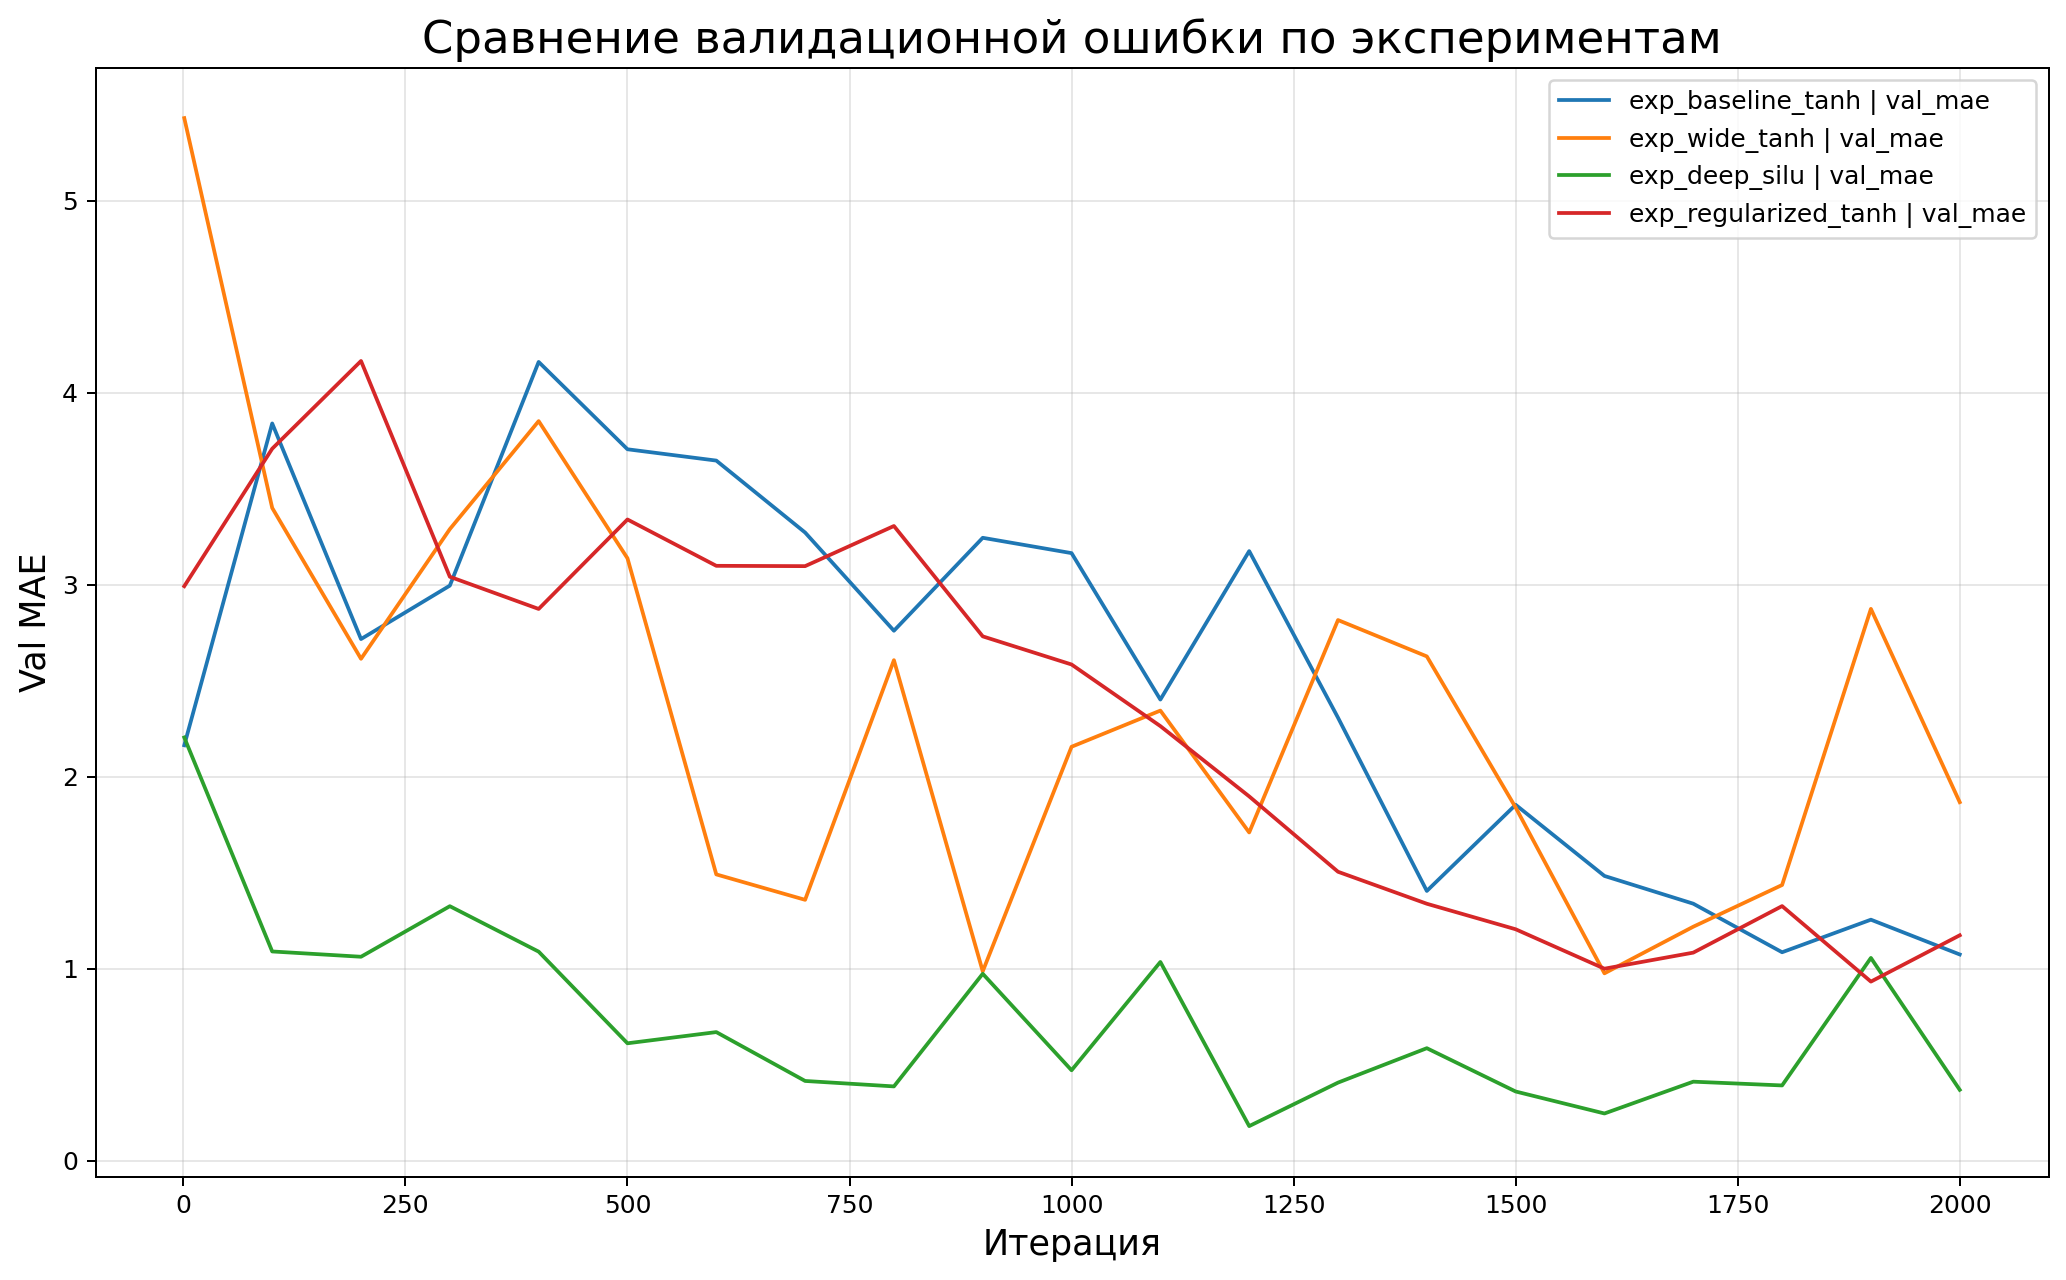

In [ ]:
plt.figure(figsize=(14, 8), dpi=180)

for experiment_name, output in experiment_outputs.items():
    history = output["history"]
    plt.plot(history["iter"], history["val_mae"], label=f"{experiment_name} | val_mae")

plt.xlabel("Итерация", fontsize=14)
plt.ylabel("Val MAE", fontsize=14)
plt.title("Сравнение валидационной ошибки по экспериментам", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("figures/val_mae_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

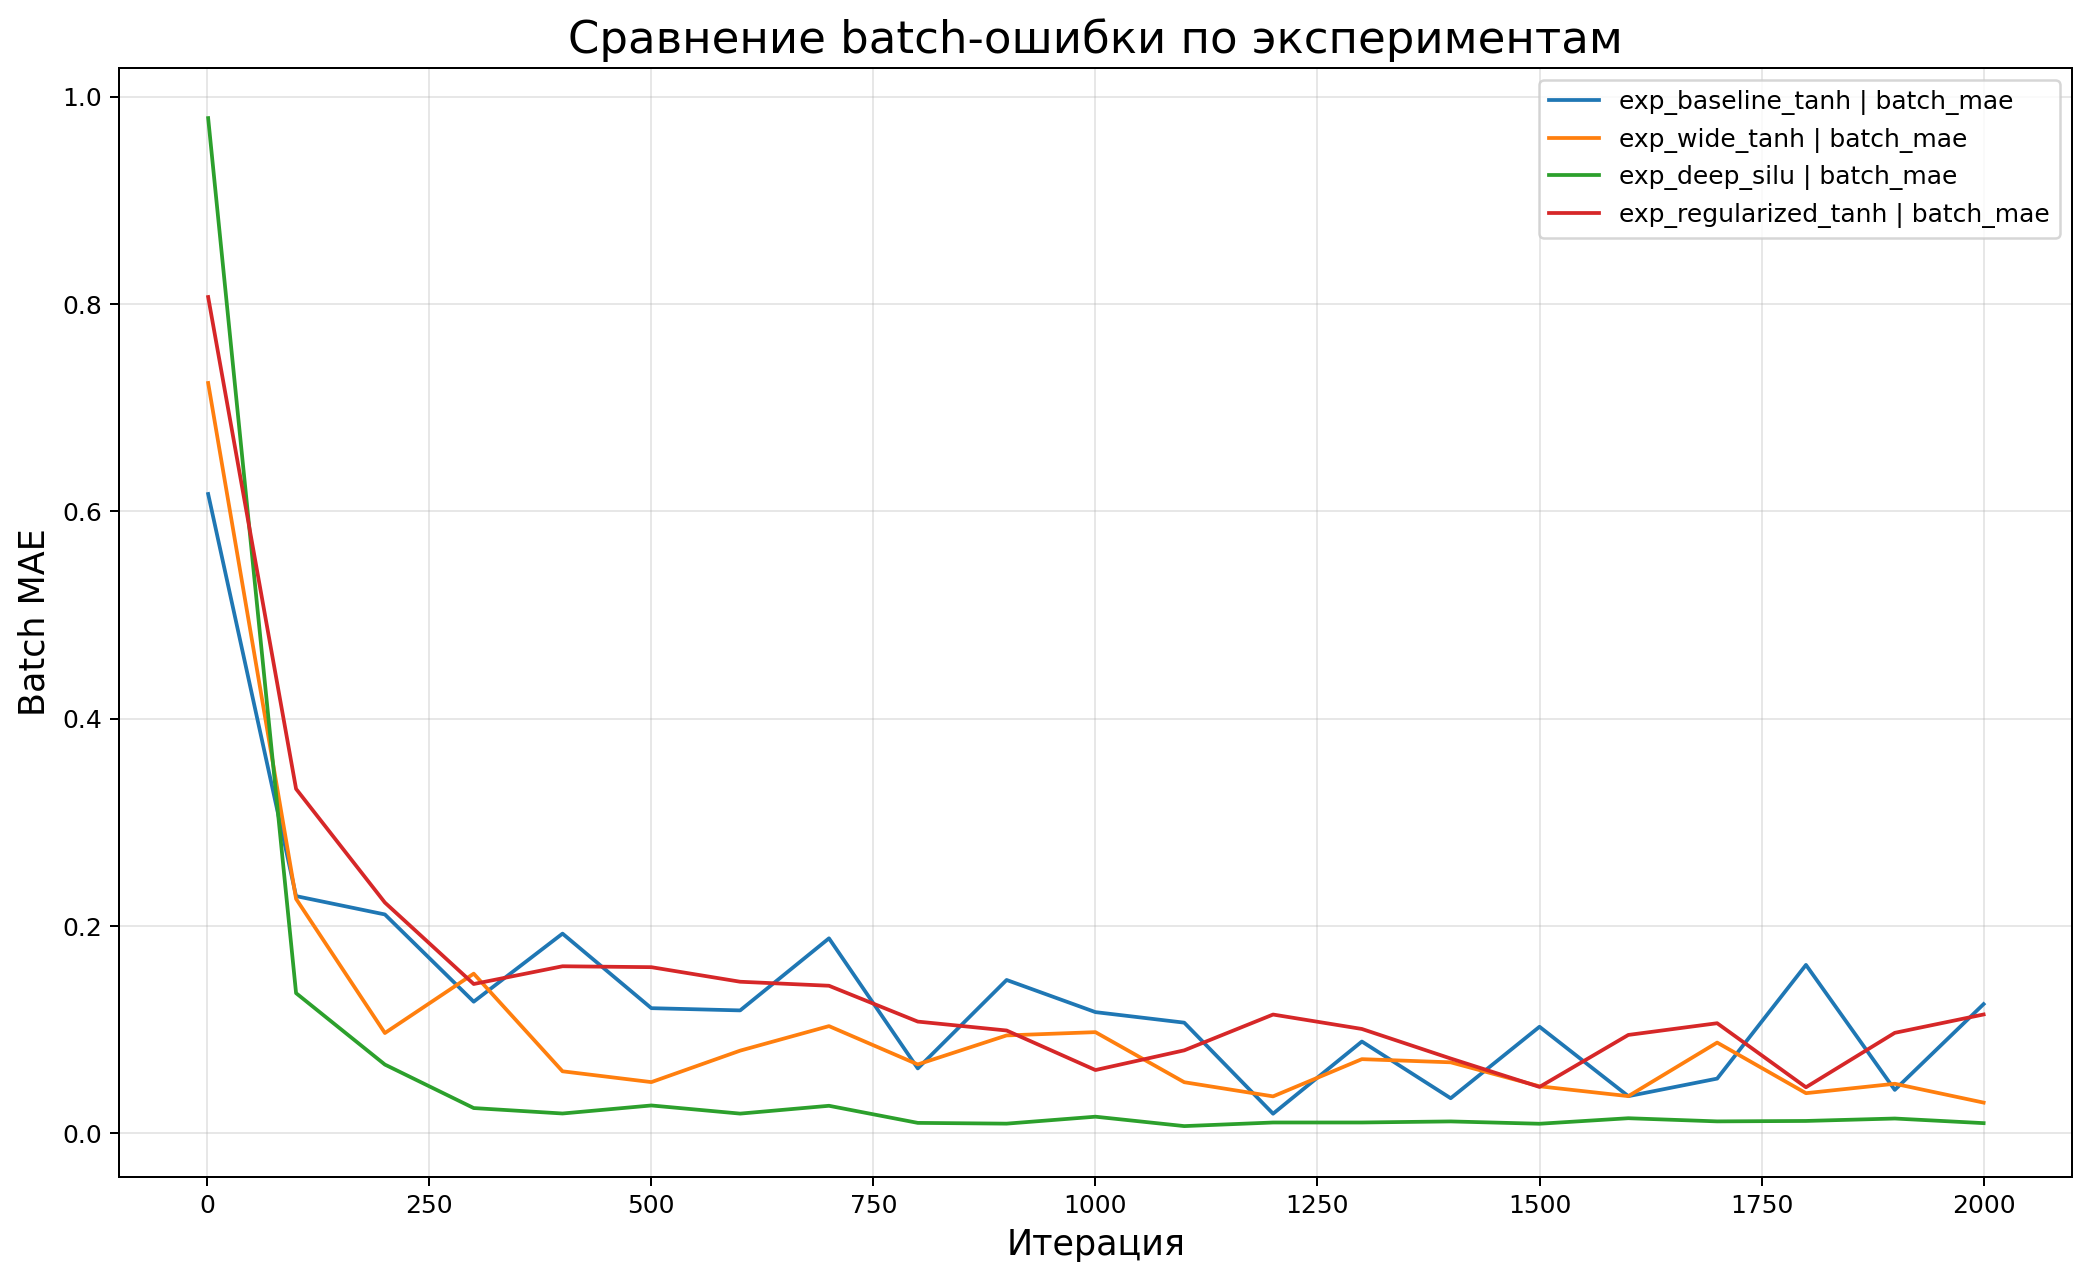

In [ ]:
plt.figure(figsize=(14, 8), dpi=180)

for experiment_name, output in experiment_outputs.items():
    history = output["history"]
    plt.plot(history["iter"], history["batch_mae"], label=f"{experiment_name} | batch_mae")

plt.xlabel("Итерация", fontsize=14)
plt.ylabel("Batch MAE", fontsize=14)
plt.title("Сравнение batch-ошибки по экспериментам", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("figures/batch_mae_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## ЛУЧШИЙ ЭКСПЕРИМЕНТ И ЕГО МЕТРИКИ

In [ ]:
best_experiment_name = results_df.loc[0, "experiment"]
best_output = experiment_outputs[best_experiment_name]

print("Лучший эксперимент:", best_experiment_name)
print()
print("Валидационные метрики:")
for key, value in best_output["val_metrics"].items():
    print(f"{key}: {value:.6f}")

print()
print("Тестовые метрики:")
for key, value in best_output["test_metrics"].items():
    print(f"{key}: {value:.6f}")

Лучший эксперимент: exp_deep_silu

Валидационные метрики:
mae: 0.180700
mse: 0.165310
rmse: 0.406583
max_ae: 6.894022
x_mae: 0.227470
y_mae: 0.208585
z_mae: 0.106044
x_rmse: 0.315391
y_rmse: 0.280667
z_rmse: 0.563634
x_r2: 0.994005
y_r2: 0.994826
z_r2: 0.937957

Тестовые метрики:
mae: 0.240988
mse: 0.230051
rmse: 0.479636
max_ae: 6.361606
x_mae: 0.305076
y_mae: 0.278081
z_mae: 0.139806
x_rmse: 0.432786
y_rmse: 0.364433
z_rmse: 0.608308
x_r2: 0.989093
y_r2: 0.991582
z_r2: 0.945214


## ВИЗУАЛИЗАЦИЯ ЛУЧШЕЙ МОДЕЛИ НА ВАЛИДАЦИИ

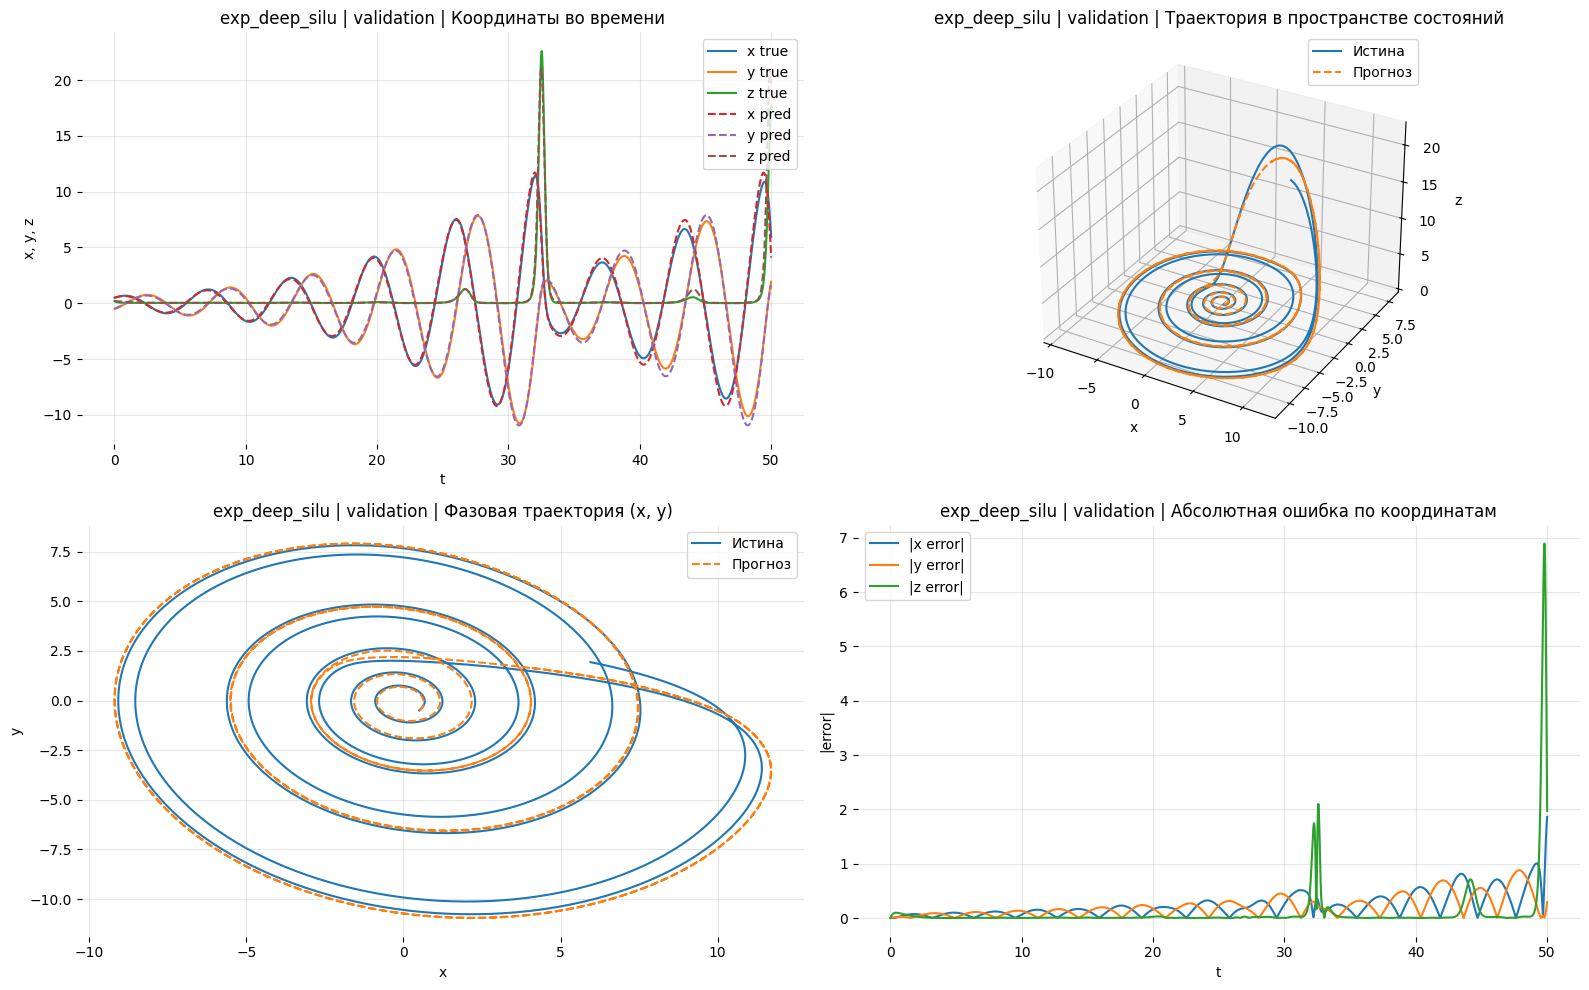

In [ ]:
visualize_trajectory(
    true_y=val_true_y,
    pred_y=best_output["val_pred_y"],
    t_grid=t,
    title_prefix=f"{best_experiment_name} | validation",
    save_path=f"figures/{best_experiment_name}_validation.png"
)

## ВИЗУАЛИЗАЦИЯ ЛУЧШЕЙ МОДЕЛИ НА ТЕСТЕ

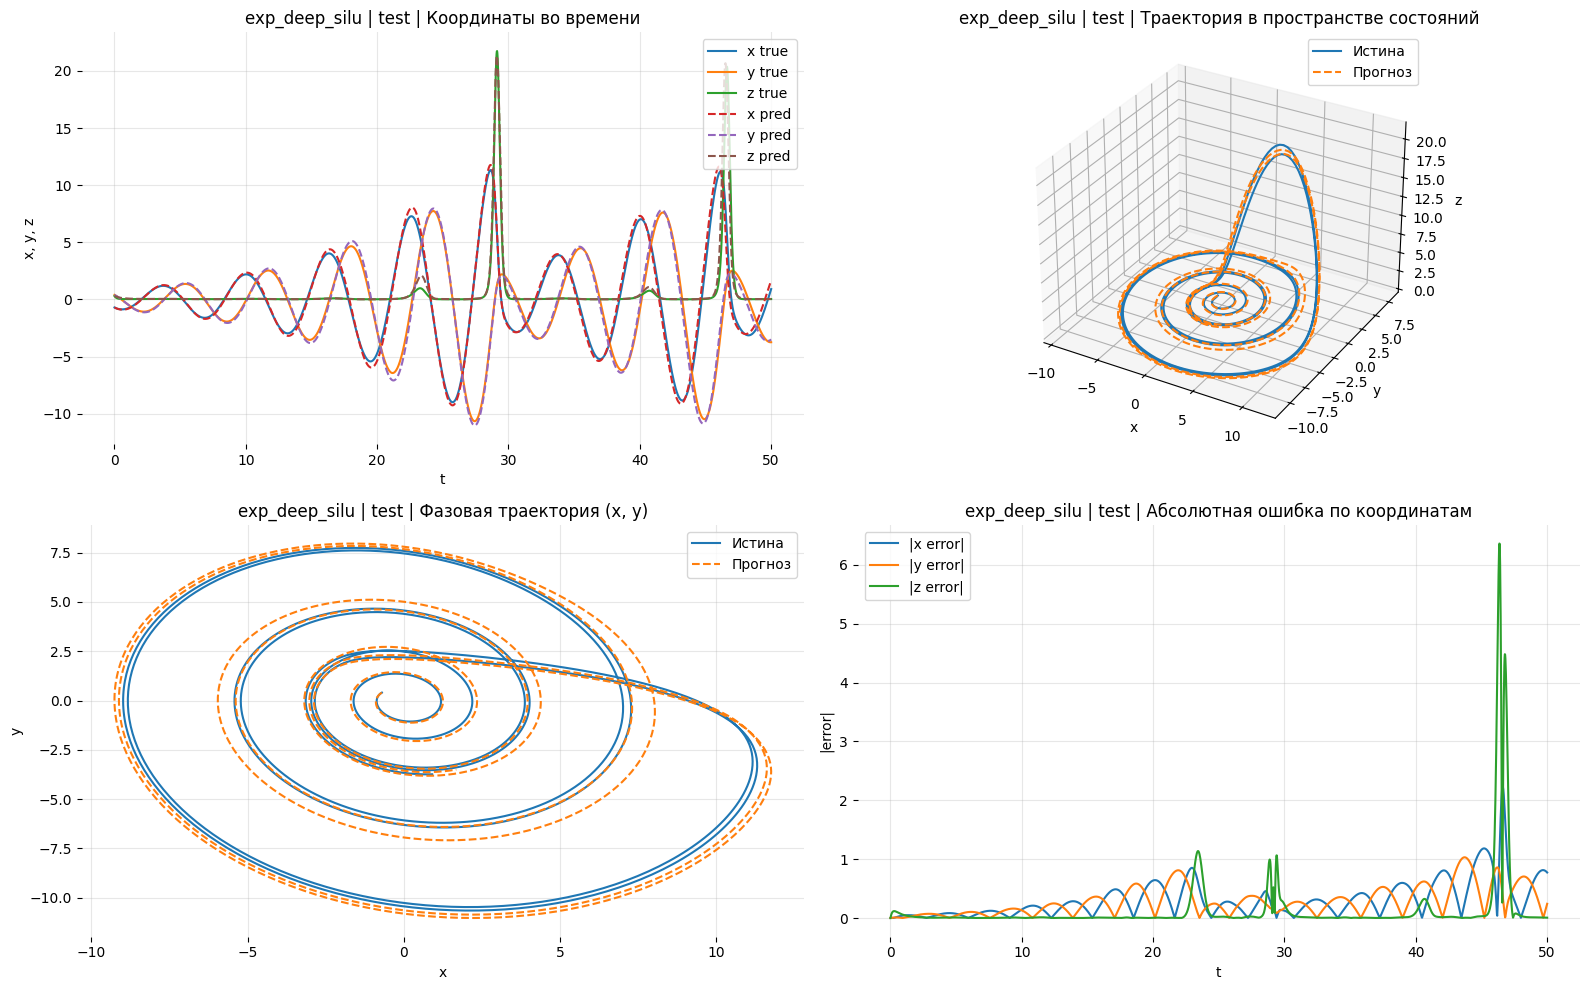

In [ ]:
visualize_trajectory(
    true_y=test_true_y,
    pred_y=best_output["test_pred_y"],
    t_grid=t,
    title_prefix=f"{best_experiment_name} | test",
    save_path=f"figures/{best_experiment_name}_test.png"
)

## SUMMARY ЛУЧШЕЙ МОДЕЛИ

In [ ]:
best_model = best_output["model"]
best_model.eval()

dummy_t = torch.tensor(0.0, dtype=torch.float32).to(device)
dummy_y = torch.randn(64, 3, dtype=torch.float32).to(device)

model_summary = summary(
    best_model,
    input_data=(dummy_t, dummy_y),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    depth=5,
    verbose=1,
    device=str(device)
)

print(model_summary)

with open("docs/torchinfo_summary_best_rossler.txt", "w", encoding="utf-8") as f:
    f.write(str(model_summary))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ODEFunc3D                                --                        [64, 3]                   --                        True
├─Sequential: 1-1                        [64, 3]                   [64, 3]                   --                        True
│    └─Linear: 2-1                       [64, 3]                   [64, 128]                 512                       True
│    └─SiLU: 2-2                         [64, 128]                 [64, 128]                 --                        --
│    └─Linear: 2-3                       [64, 128]                 [64, 128]                 16,512                    True
│    └─SiLU: 2-4                         [64, 128]                 [64, 128]                 --                        --
│    └─Linear: 2-5                       [64, 128]                 [64, 128]                 16,512                    True
│    └─

## ТЕКСТОВЫЙ ЛОГ ПО ЛУЧШЕМУ ЭКСПЕРИМЕНТУ

In [ ]:
log_text = f"""Neural ODE Rossler Experiment Log
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Device: {device}

Best experiment: {best_experiment_name}

Rossler parameters:
a = {a}
b = {b}
c = {c}

Best configuration:
{results_df.loc[0].to_dict()}

Validation metrics:
{best_output['val_metrics']}

Test metrics:
{best_output['test_metrics']}
"""

with open("results/best_rossler_experiment_log.txt", "w", encoding="utf-8") as f:
    f.write(log_text)

print("Файл results/best_rossler_experiment_log.txt сохранён")

Файл results/best_rossler_experiment_log.txt сохранён


## КРАТКИЙ ВЫВОД

- **val_mae / test_mae** — средняя абсолютная ошибка на всей траектории;
- **rmse** — сильнее штрафует крупные отклонения;
- **max_ae** — показывает максимальный промах модели;
- **R² по координатам x, y, z** — показывает, насколько хорошо восстановлена динамика по каждой координате.

Лучшую модель логично выбирать не по batch-ошибке, а по **валидационной ошибке на полной траектории**, потому что именно она лучше отражает способность модели восстанавливать непрерывную динамику, а не только локальные короткие окна обучения.

Improved Neural ODE Rossler Experiment Log
Rossler parameters: a = 0.2, b = 0.2, c = 5.7
Training parameters:
batch_size = 64
batch_time = 30
data_size = 2500
niters = 2500
test_freq = 100
lr = 0.0005
weight_decay = 1e-05
grad_clip = 1.0
terminal_weight = 0.3
solver = dopri5
Model:
hidden_dims = (128, 128, 128, 64)
activation = silu
Best checkpoint:
iter = 2500
val_mae = 0.217891
Validation metrics: MAE = 0.217891, RMSE = 0.361921, max AE = 3.111601
Test metrics: MAE = 0.084389, RMSE = 0.195148, max AE = 2.090302


Neural ODE Rossler Experiment Log
Best experiment: exp_deep_silu
Rossler parameters: a = 0.2, b = 0.2, c = 5.7
Best configuration:
hidden_dims = (128, 128, 128, 64)
activation = silu
lr = 0.0005
weight_decay = 1e-05
batch_size = 64
batch_time = 30
solver = dopri5
best_iter = 1200
val_mae = 0.18069985508918762
val_rmse = 0.4065828243808072
test_mae = 0.24098782241344452
test_rmse = 0.4796363007996468
test_x_r2 = 0.9890926480293274
test_y_r2 = 0.9915816783905029
test_z_r2 = 0.9452140927314758
